**Importing all Necassary libraries**

In [1]:
import pandas as pd
import joblib
import os
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'pandas'

**Load dataset and see the header of the dataset**

In [20]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "Crop_recommendation.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH}")
print(df.head())


    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


***Info of the dataset to see null values***
**; As there are 2200 entries and non null is also 2220 so no any null values**

In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


 **Define X and Y features and label respectively**

In [22]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[features]

le = LabelEncoder()
y = le.fit_transform(df["label"])


**Split the test and train data set which is 80:20**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Random Forest**

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)



**Evaluate Random Forest using accuracy, precision, recall, and F1-score**

In [27]:
results = {
    "Algorithm": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, rf_pred)],
    "Precision": [precision_score(y_test, rf_pred, average="weighted")],
    "Recall": [recall_score(y_test, rf_pred, average="weighted")],
    "F1-Score": [f1_score(y_test, rf_pred, average="weighted")],
}


**Print the result**

In [28]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Accuracy", ascending=False)


,Algorithm,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.993182,0.993735,0.993182,0.993175
0,Decision Tree,0.986364,0.986806,0.986364,0.986315
2,KNN,0.970455,0.973976,0.970455,0.970311


**Confusion Matrix of Random Forest**

In [29]:
output_dir = "flowchart"

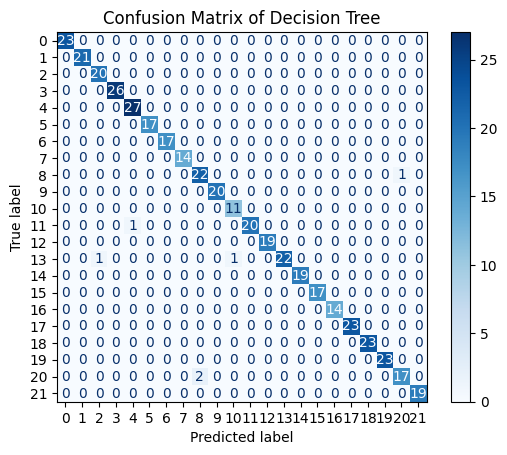

In [40]:
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Greens")
plt.title("Confusion Matrix of Random Forest")
plt.savefig(f"{output_dir}/random_forest_confusion_matrix.png", dpi=400, bbox_inches="tight")
plt.show()




**Confusion Matrix of Random Forest**

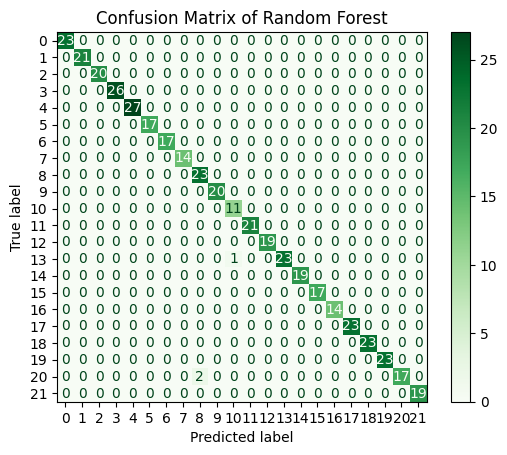

In [31]:
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Greens")
plt.title("Confusion Matrix of Random Forest")
plt.savefig(f"{output_dir}/random_forest_confusion_matrix.png",
            dpi=400, bbox_inches="tight")
plt.show()


**KNN confusion matrix removed (Random Forest only)**


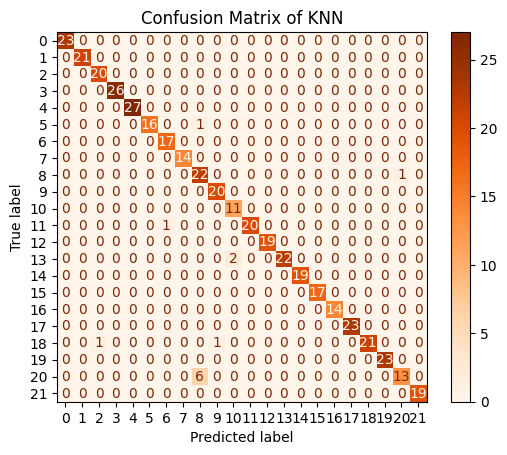

In [32]:
# Random Forest only workflow: KNN confusion matrix removed.


**Testing model with new data**

In [33]:
unseen_data = np.array([
    [90, 40, 40, 21.0, 80.0, 6.5, 200.0],   # rice-like conditions
    [60, 55, 44, 25.0, 70.0, 7.0, 120.0],   # maize-like conditions
    [20, 30, 10, 30.0, 60.0, 5.5, 50.0],    # cotton-like conditions
    [85, 45, 45, 22.0, 85.0, 6.8, 250.0]    # high rainfall crop
])


**Predict using Random Forest model**

In [34]:
rf_unseen_pred = rf_model.predict(unseen_data)


E:\IIC stuff\third year\AI\week04\Workshop\Workshop\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\IIC stuff\third year\AI\week04\Workshop\Workshop\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
E:\IIC stuff\third year\AI\week04\Workshop\Workshop\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


**Convert Random Forest numeric predictions back to crop names**

In [35]:
rf_crops = le.inverse_transform(rf_unseen_pred)


**Print Result**

In [36]:
unseen_results = pd.DataFrame({
    "Sample": ["Sample 1", "Sample 2", "Sample 3", "Sample 4"],
    "Random Forest Prediction": rf_crops,
})

unseen_results


,Sample,Decision Tree Prediction,Random Forest Prediction,KNN Prediction
0,Sample 1,rice,rice,rice
1,Sample 2,coffee,jute,papaya
2,Sample 3,mothbeans,mothbeans,mothbeans
3,Sample 4,rice,rice,rice


## **Save Random Forest model to export directory**

In [37]:
export_dir = PROJECT_ROOT / "export"
os.makedirs(export_dir, exist_ok=True)
print(f"Export directory: {export_dir}")


In [38]:
joblib.dump(rf_model, export_dir / "crop_recommendation_random_forest_model.pkl")
joblib.dump(le, export_dir / "crop_recommendation_label_encoder.pkl")


['trained_model/label_encoder.pkl']

#### **Accuracy precision F1 & Recall**

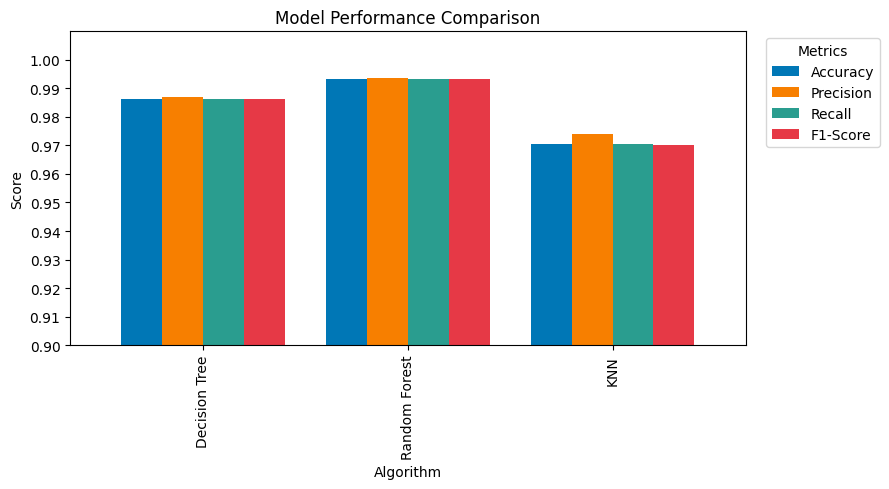

In [39]:
colors = ["#0077B6", "#F77F00", "#2A9D8F", "#E63946"]


fig, ax = plt.subplots(figsize=(9, 5))

results_df.set_index("Algorithm").plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=colors
)

# Zoom Y-axis
ax.set_ylim(0.9, 1.01)
ax.set_yticks(np.arange(0.90, 1.01, 0.01))

# Labels & title
ax.set_ylabel("Score")
ax.set_xlabel("Algorithm")
ax.set_title("Model Performance Comparison")

# Legend outside
ax.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
# Save figure
plt.savefig(f"{output_dir}/model_performance_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()
